**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.
2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [182]:
# Importing the required packages and modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

In [183]:
# Loading in the Data
df = pd.read_csv("https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv")
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


Question 1

In [184]:
# Calculating average Price and average Review Scores Rating by Neighborhood
neigh_df = df.iloc[:,0:3].groupby('Neighbourhood ').agg(['mean'])

In [185]:
neigh_df

,Price,Review Scores Rating
,mean,mean
Neighbourhood,,
Bronx,75.276498,91.654378
Brooklyn,127.747378,92.363497
Manhattan,183.664286,91.801496
Queens,96.857233,91.549057
Staten Island,146.166667,90.843750


The most expensive borough on average is Manhattan.

<Axes: xlabel='Price', ylabel='Density'>

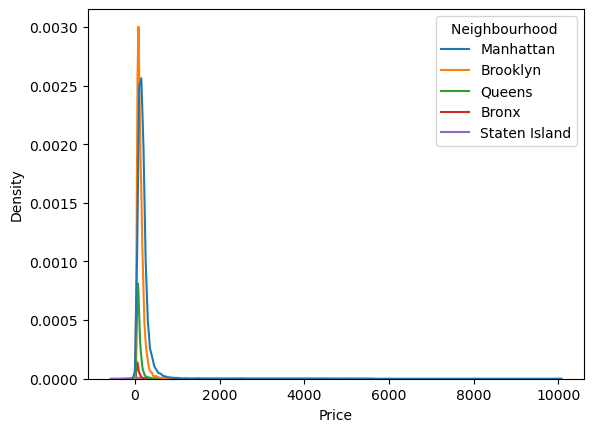

In [186]:
# kdeplot of Price, grouped by Neighborhood
sns.kdeplot(df, x="Price", hue='Neighbourhood ')

<Axes: xlabel='log_Price', ylabel='Density'>

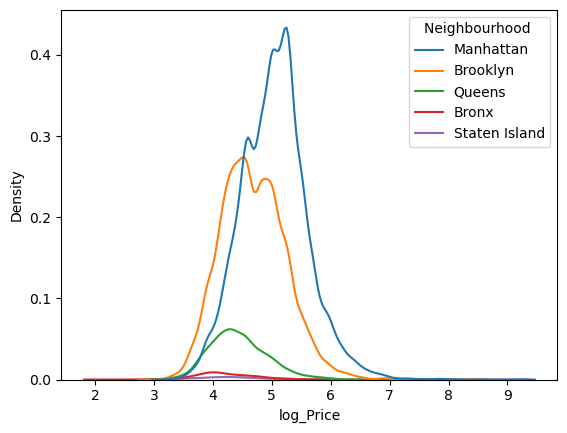

In [187]:
# kdeplot of log Price, grouped by Neighborhood
df['log_Price'] = np.log(df['Price'])
sns.kdeplot(df, x="log_Price", hue='Neighbourhood ')

Question 2

In [188]:
# Category change function
def category_change(df,datatype:str):
    category_list = list(df.select_dtypes(datatype))
    df[category_list] = df[category_list].astype('category')
    return df
df_no_int = category_change(df,'string')

In [189]:
# Creating a list of names of Property Types to keep so that all others can be changed to Other
keep_props = ['Apartment','House','Loft']

In [190]:
# Changing property to only four groups for simplicity
df_no_int['Property Type'] = df_no_int['Property Type'].apply(lambda x: "Other" if x not in keep_props else x)

In [191]:
# One-hot encoding
df_no_int = pd.get_dummies(df_no_int, columns = ['Neighbourhood ','Property Type', 'Room Type'], drop_first = False, prefix = ['Neigh','Prop', 'Room'])

In [192]:
df_no_int[["Neigh_Bronx",'Neigh_Brooklyn','Neigh_Manhattan','Neigh_Queens','Neigh_Staten Island']].sum()

Neigh_Bronx              217
Neigh_Brooklyn          8487
Neigh_Manhattan        11763
Neigh_Queens            1590
Neigh_Staten Island       96
dtype: int64

In [193]:
# Simple example: predict Price from Neighborhood - specifically Brooklyn
X_simple = df_no_int['Neigh_Brooklyn'].values.reshape(-1,1)  # sklearn expects 2D array for features
y_target = df_no_int['Price'].values.reshape(-1,1)

# Without intercept, fit_intercept=false, (then).fit
model_without = LinearRegression(fit_intercept=False).fit(X_simple, y_target)

print(f"Without Intercept: {model_without.coef_[0]}")

Without Intercept: [127.74737834]


By comparing the coefficient to the table from part 1, we can see that without a y-intercept value, the coefficient is equal to the mean of the data in Price for Brooklyn. Therefore, for each resident that lives in the Brooklyn Neighborhood data, there is a increase of $127.74 in Price per night compared to people in other Neighborhoods.

Question 3

In [194]:
# Category change function
def category_change(df,datatype:str):
    category_list = list(df.select_dtypes(datatype))
    df[category_list] = df[category_list].astype('category')
    return df
df_with_int = category_change(df,'string')

In [195]:
# Creating a list of names of Property Types to keep so that all others can be changed to Other
keep_props = ['Apartment','House','Loft']
# Changing property to only four groups for simplicity
df_with_int['Property Type'] = df_with_int['Property Type'].apply(lambda x: "Other" if x not in keep_props else x)

In [196]:
# One-hot encoding - need to drop first column to avoid multicollinearity this time
df_with_int = pd.get_dummies(df_with_int, columns = ['Neighbourhood ','Property Type', 'Room Type'], drop_first = True, prefix = ['Neigh','Prop', 'Room'])

In [197]:
# Simple example: predict Price from Neighborhood - specifically Brooklyn
X_simple = df_with_int["Neigh_Brooklyn"].values.reshape(-1,1)  # sklearn expects 2D array for features
y_target = df_with_int["Price"].values.reshape(-1,1)

# With intercept (default), fit_intercept=true/false, (then).fit
model_with = LinearRegression(fit_intercept=True).fit(X_simple, y_target)

print(f"With Intercept: {model_with.coef_[0]}, Intercept: {model_with.intercept_[0]}")

With Intercept: [-43.83267434], Intercept: 171.58005268549672


Dummies have to have drop_first = True because you need to avoid multicollinearity, which is when independent variables are highly correlated and therefore do not create an indicative predictive model. The intercept is 171.58. For each resident living in Brooklyn, there is an decrease of cost of $43.83 compared to living in other neighborhoods. You can get the coefficients from part 2 by adding the intercept from part 3 to the coefficient from part 3.

Question 4

In [210]:
# Standardize the data first
def normalize(df,datatype:str):
    numeric = list(df.select_dtypes(datatype))
    df[numeric] = MinMaxScaler().fit_transform(df[numeric])
    return df
df_with_int = normalize(df_with_int,"number")

In [211]:
# Selecting features and preparing arrays for split
features = ['Review Scores Rating','Neigh_Brooklyn','Neigh_Manhattan','Neigh_Queens','Neigh_Staten Island']
X = df_with_int[features].dropna()
# use the same target variable, but drop rows with missing features
y = df_with_int.loc[X.index, 'Price']

In [212]:
# Training and testing data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

In [213]:
# Creating Linear Regression model on the training data
model = LinearRegression().fit(X_train, y_train)

In [214]:
# Predicting values to calculate RMSE
y_pred = model.predict(X_test)
# Calculate and print RMSE and R²
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"R Squared Error: {r2}\nRoot Mean Squared Error: {rmse}")

R Squared Error: 0.06976682749654417
Root Mean Squared Error: 0.011787727428050641


In [215]:
# Printing coefficient of Review Scores Rating
print(f"Coefficient of Review Scores Rating: {model.coef_[0]}")

Coefficient of Review Scores Rating: 0.008710990344961932


In [227]:
# Printing Coefficients to see what is the most expensive place to rent
print(f"Coefficients: {model.coef_}")

Coefficients: [0.00871099 0.00517643 0.01084015 0.00202418 0.00881918]


The most expensive place to rent is in Manhattan because when you live in Manhattan, your price of rent increases the most compared to other property types.

Question 5

In [218]:
# Selecting features and preparing arrays for split
features = ['Review Scores Rating','Neigh_Brooklyn','Neigh_Manhattan','Neigh_Queens','Neigh_Staten Island','Prop_House','Prop_Loft','Prop_Other']
X1 = df_with_int[features].dropna()
# use the same target variable, but drop rows with missing features
y1 = df_with_int.loc[X.index, 'Price']

In [219]:
# Training and testing data split
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=24)

In [220]:
# Creating Linear Regression model on the training data
model1 = LinearRegression().fit(X_train1, y_train1)

In [221]:
# Predicting values to calculate RMSE
y_pred1 = model1.predict(X_test1)
# Calculate and print RMSE and R²
mse1 = mean_squared_error(y_test1, y_pred1)
rmse1 = np.sqrt(mse1)
r2_again = r2_score(y_test1, y_pred1)
print(f"R Squared Error: {r2_again}\nRoot Mean Squared Error: {rmse1}")

R Squared Error: 0.08436720029070532
Root Mean Squared Error: 0.011694855077969179


In [223]:
# Printing coefficient of Review Scores Rating
print(f"Coefficient of Review Scores Rating: {model1.coef_[0]}")

Coefficient of Review Scores Rating: 0.008780608301096693


In [240]:
# Printing Coefficients to see what is the most expensive place to rent
print(f"Coefficients: {model1.coef_[5:8]}")

Coefficients: [0.00342539 0.00600662 0.00139371]


The most expensive property type to rent is a Loft because there is the highest increase of price for Loft's for each l

Question 6

The coefficient for Review Scores Rating changing from part 4 to part 5 is because for multiple linear regression, when more or different features are used to predict the target variable, the coefficients change for each feature because they are each used in different capacities to predict the target compared to the original prediction model.